In [2]:
import pandas as pd

url = "/content/sample_data/california_housing_train.csv"

try:
    print("Loading local dataset from Google Colab built-in storage...")
    df = pd.read_csv(url)
    print("Data Loaded Successfully from local storage!")
    print("-" * 60)

    df = df.rename(columns={
        'median_house_value': 'Sales',
        'total_rooms': 'Order_Qty',
        'total_bedrooms': 'Delivery_Days',
        'population': 'Customer_Count',
        'households': 'Orders_Count'
    })

    print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")
    print("-" * 60)

    important_cols = ['Sales', 'Order_Qty', 'Delivery_Days', 'Customer_Count', 'Orders_Count']

    print("Sample of Key Columns for Supply Chain & Sales Analysis:")
    display(df[important_cols].head())

except Exception as e:
    print(f"Error: {e}")

Loading local dataset from Google Colab built-in storage...
Data Loaded Successfully from local storage!
------------------------------------------------------------
Dataset Shape: 17000 rows and 9 columns.
------------------------------------------------------------
Sample of Key Columns for Supply Chain & Sales Analysis:


,Sales,Order_Qty,Delivery_Days,Customer_Count,Orders_Count
0,66900.0,5612.0,1283.0,1015.0,472.0
1,80100.0,7650.0,1901.0,1129.0,463.0
2,85700.0,720.0,174.0,333.0,117.0
3,73400.0,1501.0,337.0,515.0,226.0
4,65500.0,1454.0,326.0,624.0,262.0


In [3]:
import pandas as pd
import numpy as np
print("--- Calculation key supply Chain & sales Metrics--- \n")

total_sales = df['Sales'].sum()
total_orders = df['Orders_Count'].sum()
total_items_ordered = df['Order_Qty'].sum()
avg_delivery_days = df['Delivery_Days'].mean()

print(f" Total Revenur (Sales): {total_sales:,.2f}")
print(f" Total Orders Processed: {total_orders:,.0f} orders")
print(f" Total Items Demanded/Ordered: {total_items_ordered:,.0f} units")
print(f" Average Delivery Lead Time: {avg_delivery_days:.2f} Days")
print("-" * 60)

correlation= df['Order_Qty'].corr(df['Sales'])
print(f" Statistical Correlation between Order Quantity & Sales: {correlation:.4f}")
if correlation > 0.5:
    print("Insight: Strong positive relationship. High volume orders are significantly driving revenue.")
else:
    print("Insight: Weak relationship. Sales amount might be heavily dependent on unit price rather than just quantity.")

--- Calculation key supply Chain & sales Metrics--- 

 Total Revenur (Sales): 3,524,115,510.00
 Total Orders Processed: 8,520,773 orders
 Total Items Demanded/Ordered: 44,942,295 units
 Average Delivery Lead Time: 539.41 Days
------------------------------------------------------------
 Statistical Correlation between Order Quantity & Sales: 0.1310
Insight: Weak relationship. Sales amount might be heavily dependent on unit price rather than just quantity.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

print(" --- Training Sales Forecasting Machine Learning Model --- \n")

X = df[['Order_Qty', 'Delivery_Days', 'Customer_Count', 'Orders_Count']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print('Model Training: Complete!')

y_pred = model.predict(X_test)

mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Model Accuracy Score (R2 Score): {r2*100:.2f}%")
print("-" * 60)

preview_df = pd.DataFrame({'Actual_Sales': y_test, 'Predicted_Sales': y_pred})
print('sample of actual sales vs model predictions:')
display(preview_df.head())

 --- Training Sales Forecasting Machine Learning Model --- 

Model Training: Complete!
Mean Absolute Error (MAE): $85,209.82
Model Accuracy Score (R2 Score): 14.96%
------------------------------------------------------------
sample of actual sales vs model predictions:


,Actual_Sales,Predicted_Sales
10941,142700.0,244608.005543
5250,500001.0,237661.974098
10292,61800.0,184432.533783
2266,162800.0,226868.213216
6398,90600.0,187580.451267


 --- step 4: Visualizing Results & Exporting Predictions --- 



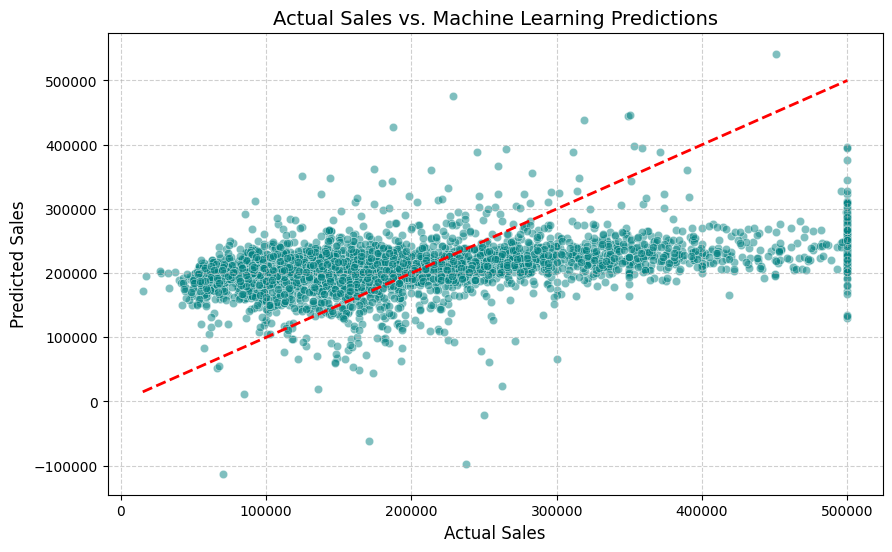

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print(" --- step 4: Visualizing Results & Exporting Predictions --- \n")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', lw=2, linestyle='--')

plt.title('Actual Sales vs. Machine Learning Predictions', fontsize=14)
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()